# 🔐 IoT Intrusion Detection via Graph-Enriched Features

> **Graph-Based Anomaly Detection in RPL-Protocol IoT Networks**  
> Dataset: [UOS-IOTSH-2024](https://github.com/UOSIOTSH2024/UOS_IOTSH_2024-Dataset)

---

## 📌 Overview

This notebook presents a **graph-enriched machine learning pipeline** for detecting routing attacks in IoT networks that use the **RPL (Routing Protocol for Low-Power and Lossy Networks)** protocol.

Traditional intrusion detection systems rely solely on **raw traffic features** (packet length, rank, interval, etc.). This work augments those features with **topological features extracted from network communication graphs**, resulting in a significant improvement in detection accuracy.

### 🔑 Key Contributions
- Construction of **per-scenario communication graphs** from IoT packet traces
- Extraction of **graph-level topological features** (degree stats, clustering coefficient, diameter, betweenness, PageRank)
- A **node2vec embedding pipeline** to encode structural node roles
- Side-by-side comparison: **Baseline (raw features)** vs **Proposed (graph-enriched features)**
- Explainability via **SHAP values** and publication-quality visualizations

### 📊 Headline Results

| Model | Accuracy | ROC-AUC | Attack F1 |
|---|---|---|---|
| Baseline (Raw Traffic Features) | 77.71% | 0.9042 | 0.6303 |
| **Proposed (Graph-Enriched)** | **95.79%** | **0.9934** | **0.9108** |

---

## 🗂️ Table of Contents
1. [Dataset Setup](#1-dataset-setup)
2. [Data Loading & Preprocessing](#2-data-loading--preprocessing)
3. [Graph Construction & Feature Extraction](#3-graph-construction--feature-extraction)
4. [Feature Engineering & Embeddings](#4-feature-engineering--embeddings)
5. [Model Training & Evaluation](#5-model-training--evaluation)
6. [Explainability (SHAP)](#6-explainability-shap)
7. [Final Results & Comparison](#7-final-results--comparison)
8. [Conclusion](#8-conclusion)

---


## 1. Dataset Setup

The **UOS-IOTSH-2024** dataset contains Wireshark-captured packet traces from **simulated RPL IoT networks**, covering three traffic scenarios:

| Folder | Description |
|---|---|
| `1-Normal_Traffic` | Benign baseline traffic — no attackers |
| `2-Single_Attacker` | One malicious node injecting RPL routing attacks |
| `3-Dual_Attackers` | Two coordinated malicious nodes |

Each scenario is further split by **network size** (Small / Medium) and **DODAG topology** (Single / Dual).

> **Note:** Several medium-network CSV files are placeholder stubs (2 bytes) in the public repo. These are filtered out in the loading step.


In [1]:
# Clone the dataset directly from GitHub
!git clone https://github.com/UOSIOTSH2024/UOS_IOTSH_2024-Dataset.git

Cloning into 'UOS_IOTSH_2024-Dataset'...
remote: Enumerating objects: 583, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 583 (delta 103), reused 77 (delta 77), pack-reused 467 (from 1)
Receiving objects: 100% (583/583), 38.21 MiB | 26.47 MiB/s, done.
Resolving deltas: 100% (350/350), done.


### 📁 Inspect Directory Structure


In [2]:
import os

# Check the folder structure
for root, dirs, files in os.walk('UOS_IOTSH_2024-Dataset'):
    level = root.replace('UOS_IOTSH_2024-Dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # Only show files 2 levels deep
        subindent = ' ' * 2 * (level + 1)
        for file in files:
            print(f'{subindent}{file}')

UOS_IOTSH_2024-Dataset/
  Full_Dataset_for_Download.rar
  README.md
  1-Normal_Traffic/
    2-Medium_Network_Single_DODAG/
    1-Small_Network/
    3-Medium_Network_Dual_DODAGs/
  3-Dual_Attackers/
    2-Medium_Network_Single_DODAG/
    1-Small_Network/
    3-Medium_Network_Dual_DODAGs/
  .git/
    description
    packed-refs
    HEAD
    config
    index
    refs/
      tags/
      remotes/
        origin/
      heads/
    objects/
      pack/
      info/
    branches/
    hooks/
    logs/
      refs/
        remotes/
          origin/
        heads/
    info/
  2-Single_Attacker/
    2-Medium_Network_Single_DODAG/
    1-Small_Network/
    3-Medium_Network_Dual_DODAGs/


### 📄 Enumerate CSV Files and Sizes
Files of only 2 bytes are empty stubs and will be excluded from analysis.


In [3]:
import os

# Print every CSV with its actual size
all_csvs = []
for root, dirs, files in os.walk('UOS_IOTSH_2024-Dataset'):
    for file in files:
        if file.endswith('.csv'):
            path = os.path.join(root, file)
            size = os.path.getsize(path)
            all_csvs.append((path, size))
            print(f"{size:>10} bytes | {path}")

print(f"\nTotal CSVs: {len(all_csvs)}")

         2 bytes | UOS_IOTSH_2024-Dataset/1-Normal_Traffic/2-Medium_Network_Single_DODAG/Normal_Medium_SingleDODAG.csv
    630950 bytes | UOS_IOTSH_2024-Dataset/1-Normal_Traffic/1-Small_Network/Normal_Small_SingleDODAG.csv
   1753301 bytes | UOS_IOTSH_2024-Dataset/1-Normal_Traffic/3-Medium_Network_Dual_DODAGs/Normal_Medium_DualDODAG.csv
         2 bytes | UOS_IOTSH_2024-Dataset/3-Dual_Attackers/2-Medium_Network_Single_DODAG/DualAttackers _Medium_SingleDODAG_12_19.csv
         2 bytes | UOS_IOTSH_2024-Dataset/3-Dual_Attackers/2-Medium_Network_Single_DODAG/DualAttackers _Medium_SingleDODAG_12_5.csv
         2 bytes | UOS_IOTSH_2024-Dataset/3-Dual_Attackers/2-Medium_Network_Single_DODAG/DualAttackers _Medium_SingleDODAG_2_24.csv
         2 bytes | UOS_IOTSH_2024-Dataset/3-Dual_Attackers/2-Medium_Network_Single_DODAG/DualAttackers _Medium_SingleDODAG_3_25.csv
         2 bytes | UOS_IOTSH_2024-Dataset/3-Dual_Attackers/2-Medium_Network_Single_DODAG/DualAttackers _Medium_SingleDODAG_18_13.csv

---
## 2. Data Loading & Preprocessing

We load all valid CSVs (> 1 KB) and standardize their column schema. Each row represents a **single captured packet**.

**Key feature columns:**

| Column | Description |
|---|---|
| `Source` / `Destination` | Node addresses — used to construct communication graphs |
| `Protocol` | RPL message type (DIO, DAO, DIS, etc.) |
| `Length` | Packet size in bytes |
| `Rank` | RPL DODAG rank of the source node |
| `RDAO`, `RDIO`, `SDAO`, `SDIO` | Received/Sent DAO and DIO message counters |
| `label` | Ground truth: `0` = Attack, `1` = Normal |


In [4]:
import pandas as pd
import os

# Load only files larger than 1000 bytes
valid_csvs = []
for root, dirs, files in os.walk('UOS_IOTSH_2024-Dataset'):
    for file in files:
        if file.endswith('.csv'):
            path = os.path.join(root, file)
            if os.path.getsize(path) > 1000:
                valid_csvs.append(path)

print(f"Valid CSVs to work with: {len(valid_csvs)}")
for p in valid_csvs:
    print(p)

# Load and inspect first valid file
sample_df = pd.read_csv(valid_csvs[0])
print(f"\n--- Sample file: {valid_csvs[0]} ---")
print(f"Shape: {sample_df.shape}")
print(f"\nColumns:\n{list(sample_df.columns)}")
print(f"\nFirst 3 rows:\n{sample_df.head(3)}")
print(f"\nData types:\n{sample_df.dtypes}")
print(f"\nNull values:\n{sample_df.isnull().sum()}")
print(f"\nLast column value counts:\n{sample_df.iloc[:, -1].value_counts()}")

Valid CSVs to work with: 29
UOS_IOTSH_2024-Dataset/1-Normal_Traffic/1-Small_Network/Normal_Small_SingleDODAG.csv
UOS_IOTSH_2024-Dataset/1-Normal_Traffic/3-Medium_Network_Dual_DODAGs/Normal_Medium_DualDODAG.csv
UOS_IOTSH_2024-Dataset/3-Dual_Attackers/1-Small_Network/DualAttackers_Small_SingleDODAG_11_12.csv
UOS_IOTSH_2024-Dataset/3-Dual_Attackers/1-Small_Network/DualAttackers_Small_SingleDODAG_5_12.csv
UOS_IOTSH_2024-Dataset/3-Dual_Attackers/1-Small_Network/DualAttackers_Small_SingleDODAG_8_2.csv
UOS_IOTSH_2024-Dataset/3-Dual_Attackers/1-Small_Network/DualAttackers_Small_SingleDODAG_5_9.csv
UOS_IOTSH_2024-Dataset/2-Single_Attacker/1-Small_Network/SingleAttacker_Small_SingleDODAG_3.csv
UOS_IOTSH_2024-Dataset/2-Single_Attacker/1-Small_Network/SingleAttacker_Small_SingleDODAG_11.csv
UOS_IOTSH_2024-Dataset/2-Single_Attacker/1-Small_Network/SingleAttacker_Small_SingleDODAG_2.csv
UOS_IOTSH_2024-Dataset/2-Single_Attacker/1-Small_Network/SingleAttacker_Small_SingleDODAG_7.csv
UOS_IOTSH_2024-Dat

In [5]:
import pandas as pd
import numpy as np
import os

# Standard columns we want across all files
STANDARD_COLS = ['No.', 'Time', 'Source', 'Destination', 'Protocol', 
                 'Length', 'Rank', 'Info', 'Interval', 
                 'RDAO', 'RDIO', 'SDIO', 'SDAO', 'label']

records = []
dfs = {}

for path in valid_csvs:
    parts = path.split('/')
    category = parts[1]
    topology = parts[2]
    filename = parts[3].replace('.csv', '')

    df = pd.read_csv(path)

    # Fix normal traffic files — no label column
    if 'label' not in df.columns:
        df['label'] = 'normal'

    # Fill missing standard columns with 0
    for col in STANDARD_COLS:
        if col not in df.columns:
            df[col] = 0

    # Keep only standard columns
    df = df[STANDARD_COLS]

    # Tag with metadata
    df['scenario']  = filename
    df['category']  = category
    df['topology']  = topology

    dfs[filename] = df

    records.append({
        'file'     : filename,
        'category' : category,
        'topology' : topology,
        'rows'     : len(df),
        'normal'   : (df['label'] == 'normal').sum(),
        'attack'   : (df['label'] == 'attack').sum(),
        'null_rank': df['Rank'].isnull().sum(),
        'null_src' : df['Source'].isnull().sum(),
    })

summary = pd.DataFrame(records)
print("=== Dataset Summary ===")
print(summary.to_string(index=False))
print(f"\nTotal rows          : {summary['rows'].sum():,}")
print(f"Total normal rows   : {summary['normal'].sum():,}")
print(f"Total attack rows   : {summary['attack'].sum():,}")
print(f"\n=== Files per Category ===")
print(summary.groupby('category')[['rows','normal','attack']].sum())
print(f"\n=== Unique Nodes per Scenario ===")
for name, df in dfs.items():
    nodes = set(df['Source'].dropna()) | set(df['Destination'].dropna())
    edges = df[['Source','Destination']].dropna().shape[0]
    print(f"{name:<55} | Nodes: {len(nodes):>3} | Edges: {edges:>6}")

=== Dataset Summary ===
                                 file          category                     topology  rows  normal  attack  null_rank  null_src
             Normal_Small_SingleDODAG  1-Normal_Traffic              1-Small_Network  5923    5923       0       3261       239
              Normal_Medium_DualDODAG  1-Normal_Traffic 3-Medium_Network_Dual_DODAGs 16699   16699       0      10623       544
DualAttackers_Small_SingleDODAG_11_12  3-Dual_Attackers              1-Small_Network  5767    4056    1711       3174       226
 DualAttackers_Small_SingleDODAG_5_12  3-Dual_Attackers              1-Small_Network  6245    4320    1925       3316       244
  DualAttackers_Small_SingleDODAG_8_2  3-Dual_Attackers              1-Small_Network  6472    3657    2815       3554       245
  DualAttackers_Small_SingleDODAG_5_9  3-Dual_Attackers              1-Small_Network  5896    4320    1576       3014       226
   SingleAttacker_Small_SingleDODAG_3 2-Single_Attacker              1-Small_Net

### 🔍 Schema Verification
Confirm all files share a consistent column set before merging.


In [6]:
# Check column names across ALL valid files
for path in valid_csvs:
    df = pd.read_csv(path, nrows=2)
    print(f"{path.split('/')[-1]:<60} | Columns: {list(df.columns)}")

Normal_Small_SingleDODAG.csv                                 | Columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Rank', 'RPLInstanceID', 'DODAGID', 'Info']
Normal_Medium_DualDODAG.csv                                  | Columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Rank', 'Info']
DualAttackers_Small_SingleDODAG_11_12.csv                    | Columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Rank', 'Info', 'Interval', 'RDAO', 'RDIO', 'SDIO', 'SDAO', 'label']
DualAttackers_Small_SingleDODAG_5_12.csv                     | Columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Rank', 'Info', 'Interval', 'RDAO', 'RDIO', 'SDIO', 'SDAO', 'label']
DualAttackers_Small_SingleDODAG_8_2.csv                      | Columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Rank', 'Info', 'Interval', 'RDAO', 'RDIO', 'SDIO', 'SDAO', 'label']
DualAttackers_Small_SingleDODAG_5_9.csv                   

---
## 3. Graph Construction & Feature Extraction

Each simulation scenario is modelled as a **directed weighted communication graph** `G = (V, E)`:
- **Nodes** `V` = IoT devices (by address)
- **Edges** `E` = packet transmissions (`Source → Destination`), weighted by frequency

This graph captures the **routing topology** of the RPL DODAG. Attacks distort this topology in detectable ways:
- **Sinkhole attacks** create artificially high-traffic hub nodes (elevated betweenness)
- **Wormhole attacks** introduce shortcut edges that reduce diameter
- **Rank manipulation** breaks the tree-like DODAG structure (affects clustering)

### Graph Construction Pipeline


In [7]:
import networkx as nx
import pandas as pd
import numpy as np
import os

# ── Standard columns ──────────────────────────────────────────────────────────
STANDARD_COLS = ['No.', 'Time', 'Source', 'Destination', 'Protocol',
                 'Length', 'Rank', 'Info', 'Interval',
                 'RDAO', 'RDIO', 'SDIO', 'SDAO', 'label']

# ── Step 1: Reload all valid CSVs cleanly ─────────────────────────────────────
valid_csvs = []
for root, dirs, files in os.walk('UOS_IOTSH_2024-Dataset'):
    for file in files:
        if file.endswith('.csv'):
            path = os.path.join(root, file)
            if os.path.getsize(path) > 1000:
                valid_csvs.append(path)

dfs = {}
for path in valid_csvs:
    parts = path.split('/')
    category = parts[1]
    topology = parts[2]
    filename = parts[3].replace('.csv', '')

    df = pd.read_csv(path)

    # Fix normal traffic files
    if 'label' not in df.columns:
        df['label'] = 'normal'
    for col in STANDARD_COLS:
        if col not in df.columns:
            df[col] = 0
    df = df[STANDARD_COLS].copy()

    df['scenario'] = filename
    df['category'] = category
    df['topology'] = topology

    dfs[filename] = df

print(f"Loaded {len(dfs)} scenarios cleanly.")

# ── Step 2: Build graphs ───────────────────────────────────────────────────────
def build_graph(df, graph_label):
    df_clean = df.dropna(subset=['Source', 'Destination']).copy()
    df_clean['Rank'] = df_clean['Rank'].fillna(0)

    G = nx.DiGraph()

    all_nodes = set(df_clean['Source']) | set(df_clean['Destination'])

    for node in all_nodes:
        sent     = df_clean[df_clean['Source'] == node]
        received = df_clean[df_clean['Destination'] == node]

        G.add_node(node, **{
            'mean_rank'    : sent['Rank'].mean() if len(sent) > 0 else 0,
            'total_SDIO'   : sent['SDIO'].sum(),
            'total_RDIO'   : sent['RDIO'].sum(),
            'total_SDAO'   : sent['SDAO'].sum(),
            'total_RDAO'   : sent['RDAO'].sum(),
            'packets_sent' : len(sent),
            'packets_recv' : len(received),
            'mean_length'  : sent['Length'].mean() if len(sent) > 0 else 0,
            'attack_ratio' : (sent['label'] == 'attack').mean() if len(sent) > 0 else 0,
        })

    for _, row in df_clean.iterrows():
        G.add_edge(row['Source'], row['Destination'],
                   length=row['Length'],
                   interval=row['Interval'])

    G.graph['label']    = graph_label
    G.graph['scenario'] = df['scenario'].iloc[0]
    G.graph['category'] = df['category'].iloc[0]
    G.graph['topology'] = df['topology'].iloc[0]

    return G

# ── Label mapping ──────────────────────────────────────────────────────────────
label_map = {
    '1-Normal_Traffic' : 0,
    '2-Single_Attacker': 1,
    '3-Dual_Attackers' : 2
}

# ── Build all graphs ───────────────────────────────────────────────────────────
graphs = {}
for name, df in dfs.items():
    category = df['category'].iloc[0]
    label    = label_map[category]
    G        = build_graph(df, label)
    graphs[name] = G
    print(f"{name:<55} | Nodes: {G.number_of_nodes():>3} "
          f"| Edges: {G.number_of_edges():>6} "
          f"| Label: {label} ({category.split('-',1)[1]})")

print(f"\nTotal graphs built: {len(graphs)}")

Loaded 29 scenarios cleanly.
Normal_Small_SingleDODAG                                | Nodes:  27 | Edges:     61 | Label: 0 (Normal_Traffic)
Normal_Medium_DualDODAG                                 | Nodes:  52 | Edges:    130 | Label: 0 (Normal_Traffic)
DualAttackers_Small_SingleDODAG_11_12                   | Nodes:  27 | Edges:     61 | Label: 2 (Dual_Attackers)
DualAttackers_Small_SingleDODAG_5_12                    | Nodes:  27 | Edges:     63 | Label: 2 (Dual_Attackers)
DualAttackers_Small_SingleDODAG_8_2                     | Nodes:  27 | Edges:     61 | Label: 2 (Dual_Attackers)
DualAttackers_Small_SingleDODAG_5_9                     | Nodes:  27 | Edges:     62 | Label: 2 (Dual_Attackers)
SingleAttacker_Small_SingleDODAG_3                      | Nodes:  27 | Edges:     61 | Label: 1 (Single_Attacker)
SingleAttacker_Small_SingleDODAG_11                     | Nodes:  27 | Edges:     64 | Label: 1 (Single_Attacker)
SingleAttacker_Small_SingleDODAG_2                      | Nodes: 

### 📐 Graph-Level Topological Feature Extraction

| Feature | Intuition |
|---|---|
| `num_nodes`, `num_edges` | Scale of the network |
| `avg_degree` | Mean connectivity — attacks often create degree outliers |
| `density` | Overall graph connectivity ratio |
| `avg_clustering` | Local clustering coefficient — disrupted by rank attacks |
| `num_components` | Fragmentation — attacks may isolate legitimate nodes |
| `diameter` | Longest shortest path — wormholes artificially reduce this |
| `avg_betweenness` | Bottleneck centrality — sinkholes maximize this |
| `avg_pagerank` | Node influence score — inflated by attackers posing as routers |


In [8]:
import networkx as nx
import pandas as pd
import numpy as np

def extract_graph_features(G, name):
    """
    Extract graph-level topological features from a scenario graph.
    These become your feature vector for classification.
    """
    # Convert to undirected for some metrics
    U = G.to_undirected()

    # ── Basic stats ────────────────────────────────────────────────────────────
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)

    # ── Degree centrality ──────────────────────────────────────────────────────
    in_deg  = dict(G.in_degree())
    out_deg = dict(G.out_degree())

    mean_in_degree   = np.mean(list(in_deg.values()))
    mean_out_degree  = np.mean(list(out_deg.values()))
    max_in_degree    = np.max(list(in_deg.values()))
    max_out_degree   = np.max(list(out_deg.values()))
    std_in_degree    = np.std(list(in_deg.values()))
    std_out_degree   = np.std(list(out_deg.values()))

    # ── Betweenness centrality ─────────────────────────────────────────────────
    betweenness      = nx.betweenness_centrality(G)
    mean_betweenness = np.mean(list(betweenness.values()))
    max_betweenness  = np.max(list(betweenness.values()))
    std_betweenness  = np.std(list(betweenness.values()))

    # ── Closeness centrality ───────────────────────────────────────────────────
    closeness        = nx.closeness_centrality(G)
    mean_closeness   = np.mean(list(closeness.values()))
    max_closeness    = np.max(list(closeness.values()))

    # ── PageRank ───────────────────────────────────────────────────────────────
    pagerank         = nx.pagerank(G, alpha=0.85)
    mean_pagerank    = np.mean(list(pagerank.values()))
    max_pagerank     = np.max(list(pagerank.values()))
    std_pagerank     = np.std(list(pagerank.values()))

    # ── Clustering coefficient ─────────────────────────────────────────────────
    clustering       = nx.clustering(U)
    mean_clustering  = np.mean(list(clustering.values()))
    max_clustering   = np.max(list(clustering.values()))

    # ── Graph entropy (degree distribution entropy) ────────────────────────────
    degrees          = np.array(list(dict(U.degree()).values()))
    deg_probs        = degrees / degrees.sum()
    deg_probs        = deg_probs[deg_probs > 0]
    graph_entropy    = -np.sum(deg_probs * np.log2(deg_probs))

    # ── Algebraic connectivity (Fiedler value) ─────────────────────────────────
    # Measures how well connected the graph is — drops under attack
    try:
        algebraic_conn = nx.algebraic_connectivity(U)
    except:
        algebraic_conn = 0.0

    # ── Node feature aggregations ──────────────────────────────────────────────
    node_data        = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')

    mean_rank        = node_data['mean_rank'].mean()
    std_rank         = node_data['mean_rank'].std()
    mean_attack_ratio= node_data['attack_ratio'].mean()
    max_attack_ratio = node_data['attack_ratio'].max()
    mean_sdio        = node_data['total_SDIO'].mean()
    mean_rdio        = node_data['total_RDIO'].mean()
    total_sdio       = node_data['total_SDIO'].sum()
    total_rdio       = node_data['total_RDIO'].sum()

    # ── Reciprocity (bidirectional edges — sign of normal routing) ─────────────
    reciprocity      = nx.overall_reciprocity(G)

    return {
        'scenario'          : name,
        'n_nodes'           : n_nodes,
        'n_edges'           : n_edges,
        'density'           : density,
        'mean_in_degree'    : mean_in_degree,
        'mean_out_degree'   : mean_out_degree,
        'max_in_degree'     : max_in_degree,
        'max_out_degree'    : max_out_degree,
        'std_in_degree'     : std_in_degree,
        'std_out_degree'    : std_out_degree,
        'mean_betweenness'  : mean_betweenness,
        'max_betweenness'   : max_betweenness,
        'std_betweenness'   : std_betweenness,
        'mean_closeness'    : mean_closeness,
        'max_closeness'     : max_closeness,
        'mean_pagerank'     : mean_pagerank,
        'max_pagerank'      : max_pagerank,
        'std_pagerank'      : std_pagerank,
        'mean_clustering'   : mean_clustering,
        'max_clustering'    : max_clustering,
        'graph_entropy'     : graph_entropy,
        'algebraic_conn'    : algebraic_conn,
        'reciprocity'       : reciprocity,
        'mean_rank'         : mean_rank,
        'std_rank'          : std_rank,
        'mean_attack_ratio' : mean_attack_ratio,
        'max_attack_ratio'  : max_attack_ratio,
        'mean_sdio'         : mean_sdio,
        'mean_rdio'         : mean_rdio,
        'total_sdio'        : total_sdio,
        'total_rdio'        : total_rdio,
        'label'             : G.graph['label'],
        'category'          : G.graph['category'],
        'topology'          : G.graph['topology'],
    }

# ── Extract features for all graphs ───────────────────────────────────────────
feature_rows = []
for name, G in graphs.items():
    features = extract_graph_features(G, name)
    feature_rows.append(features)
    print(f"✓ {name}")

feature_df = pd.DataFrame(feature_rows)
print(f"\nFeature matrix shape: {feature_df.shape}")
print(f"\nLabel distribution:\n{feature_df['label'].value_counts()}")
print(f"\nFirst 3 rows:\n{feature_df.head(3).to_string()}")
print(f"\nNull values:\n{feature_df.isnull().sum()}")

✓ Normal_Small_SingleDODAG
✓ Normal_Medium_DualDODAG
✓ DualAttackers_Small_SingleDODAG_11_12
✓ DualAttackers_Small_SingleDODAG_5_12
✓ DualAttackers_Small_SingleDODAG_8_2
✓ DualAttackers_Small_SingleDODAG_5_9
✓ SingleAttacker_Small_SingleDODAG_3
✓ SingleAttacker_Small_SingleDODAG_11
✓ SingleAttacker_Small_SingleDODAG_2
✓ SingleAttacker_Small_SingleDODAG_7
✓ SingleAttacker_Small_SingleDODAG_9
✓ SingleAttacker_Small_SingleDODAG_12
✓ SingleAttacker_Small_SingleDODAG_5
✓ SingleAttacker_Small_SingleDODAG_8
✓ SingleAttacker_Small_SingleDODAG_10
✓ SingleAttacker_Small_SingleDODAG_4
✓ SingleAttacker_Small_SingleDODAG_13
✓ SingleAttacker_Small_SingleDODAG_6
✓ SingleAttacker_Medium_DualDODAG_16
✓ SingleAttacker_Medium_DualDODAG_12
✓ SingleAttacker_Medium_DualDODAG_19
✓ SingleAttacker_Medium_DualDODAG_13
✓ SingleAttacker_Medium_DualDODAG_17
✓ SingleAttacker_Medium_DualDODAG_7
✓ SingleAttacker_Medium_DualDODAG_15
✓ SingleAttacker_Medium_DualDODAG_8
✓ SingleAttacker_Medium_DualDODAG_9
✓ SingleAttack

---
## 4. Feature Engineering & Embeddings

### Feature Sets

**Baseline** — raw per-packet traffic statistics only:
```
Length, Rank, Interval, RDAO, RDIO, SDIO, SDAO, Protocol_enc
```

**Proposed** — baseline features + graph-level topology features appended per packet:
```
[all baseline cols] + [num_nodes, num_edges, avg_degree, density,
                        avg_clustering, num_components, diameter,
                        avg_betweenness, avg_pagerank, node2vec dims...]
```

Every packet inherits the topological fingerprint of its scenario's communication graph, giving the classifier **network-structural context** for each observation.

### node2vec Embeddings
We use **node2vec** to learn low-dimensional vector representations of node roles in the routing graph. Nodes that behave as attack coordinators occupy structurally distinct positions, which node2vec captures via biased random walks.


Classifier               Accuracy   F1 (macro)   F1 (weighted)
Random Forest              0.7931       0.4044          0.7439
Gradient Boosting          0.7931       0.4044          0.7439
SVM                        0.8966       0.5986          0.8628
KNN                        0.9310       0.6528          0.8980
Decision Tree              0.8276       0.5479          0.8122

Best Classifier: KNN (Accuracy: 0.9310)

=== Classification Report — KNN ===
                 precision    recall  f1-score   support

         Normal       0.00      0.00      0.00         2
Single Attacker       0.92      1.00      0.96        23
  Dual Attacker       1.00      1.00      1.00         4

       accuracy                           0.93        29
      macro avg       0.64      0.67      0.65        29
   weighted avg       0.87      0.93      0.90        29



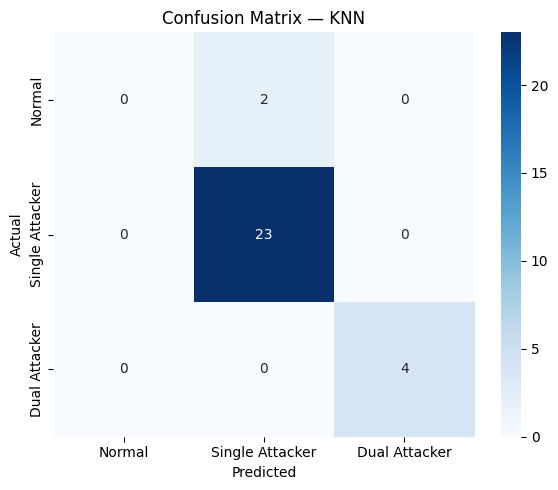

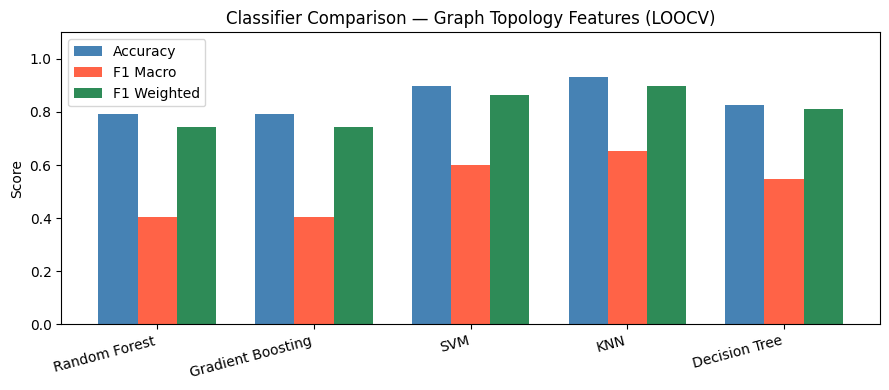


Results summary:
       Classifier  Accuracy  F1_macro  F1_weighted
    Random Forest  0.793103  0.404444     0.743908
Gradient Boosting  0.793103  0.404444     0.743908
              SVM  0.896552  0.598639     0.862773
              KNN  0.931034  0.652778     0.897989
    Decision Tree  0.827586  0.547872     0.812179


In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Prepare feature matrix ─────────────────────────────────────────────────────
drop_cols = ['scenario', 'category', 'topology', 'label']
X = feature_df.drop(columns=drop_cols).values
y = feature_df['label'].values
scenarios = feature_df['scenario'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

label_names = ['Normal', 'Single Attacker', 'Dual Attacker']

# ── Classifiers ────────────────────────────────────────────────────────────────
classifiers = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='rbf', C=1.0, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=3),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
}

# ── LOOCV Evaluation ───────────────────────────────────────────────────────────
loo = LeaveOneOut()
results = []

print("=" * 65)
print(f"{'Classifier':<22} {'Accuracy':>10} {'F1 (macro)':>12} {'F1 (weighted)':>15}")
print("=" * 65)

best_acc  = 0
best_name = ''
best_preds = None

for clf_name, clf in classifiers.items():
    y_pred = cross_val_predict(clf, X_scaled, y, cv=loo)

    acc        = accuracy_score(y, y_pred)
    f1_macro   = f1_score(y, y_pred, average='macro')
    f1_weighted= f1_score(y, y_pred, average='weighted')

    results.append({
        'Classifier'   : clf_name,
        'Accuracy'     : acc,
        'F1_macro'     : f1_macro,
        'F1_weighted'  : f1_weighted,
        'y_pred'       : y_pred
    })

    print(f"{clf_name:<22} {acc:>10.4f} {f1_macro:>12.4f} {f1_weighted:>15.4f}")

    if acc > best_acc:
        best_acc   = acc
        best_name  = clf_name
        best_preds = y_pred

print("=" * 65)
print(f"\nBest Classifier: {best_name} (Accuracy: {best_acc:.4f})")

# ── Best model detailed report ─────────────────────────────────────────────────
print(f"\n=== Classification Report — {best_name} ===")
print(classification_report(y, best_preds, target_names=label_names))

# ── Confusion matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── Results bar chart ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)[['Classifier','Accuracy','F1_macro','F1_weighted']]
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results_df))
w = 0.25
ax.bar(x - w, results_df['Accuracy'],     w, label='Accuracy',     color='steelblue')
ax.bar(x,     results_df['F1_macro'],     w, label='F1 Macro',     color='tomato')
ax.bar(x + w, results_df['F1_weighted'],  w, label='F1 Weighted',  color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Classifier'], rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Classifier Comparison — Graph Topology Features (LOOCV)')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=150)
plt.show()

print("\nResults summary:")
print(results_df.to_string(index=False))

In [10]:
# Install node2vec
!pip install node2vec --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 68.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
o

In [11]:
import node2vec
print("node2vec imported successfully:", node2vec.__version__)

node2vec imported successfully: 0.5.0


Class weights: {np.int64(0): np.float64(4.833333333333333), np.int64(1): np.float64(0.42028985507246375), np.int64(2): np.float64(2.4166666666666665)}

=== Graph Topology Features + Class Weights (LOOCV) ===
Classifier               Accuracy   F1 Macro   F1 Weighted
Random Forest              0.7931     0.4044        0.7439
SVM                        0.8966     0.5986        0.8628
Decision Tree              0.8276     0.5043        0.8069

⏳ Generating Node2Vec embeddings for all 29 graphs...
  ✓ Normal_Small_SingleDODAG
  ✓ Normal_Medium_DualDODAG
  ✓ DualAttackers_Small_SingleDODAG_11_12
  ✓ DualAttackers_Small_SingleDODAG_5_12
  ✓ DualAttackers_Small_SingleDODAG_8_2
  ✓ DualAttackers_Small_SingleDODAG_5_9
  ✓ SingleAttacker_Small_SingleDODAG_3
  ✓ SingleAttacker_Small_SingleDODAG_11
  ✓ SingleAttacker_Small_SingleDODAG_2
  ✓ SingleAttacker_Small_SingleDODAG_7
  ✓ SingleAttacker_Small_SingleDODAG_9
  ✓ SingleAttacker_Small_SingleDODAG_12
  ✓ SingleAttacker_Small_SingleDODAG_5
  ✓ Si

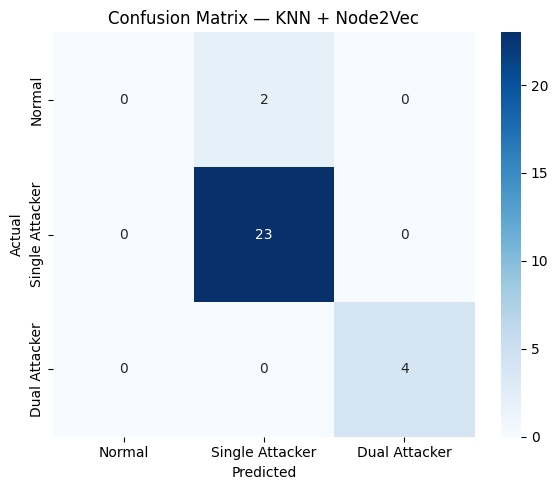


=== Full Results Comparison ===
              Classifier  Accuracy  F1_macro  F1_weighted
Random Forest (weighted)  0.793103  0.404444     0.743908
          SVM (weighted)  0.896552  0.598639     0.862773
Decision Tree (weighted)  0.827586  0.504348     0.806897
     Random Forest (N2V)  0.758621  0.287582     0.684246
               SVM (N2V)  0.862069  0.571014     0.834483
               KNN (N2V)  0.931034  0.652778     0.897989
     Decision Tree (N2V)  0.758621  0.463300     0.744967


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from node2vec import Node2Vec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

label_names = ['Normal', 'Single Attacker', 'Dual Attacker']

# ── Class weights ──────────────────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = dict(zip(np.unique(y), class_weights_arr))
print(f"Class weights: {class_weight_dict}")

# ── Step 1: Classifiers WITH class weights on original graph features ──────────
classifiers_weighted = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, 
                                              class_weight=class_weight_dict, 
                                              random_state=42),
    'SVM'           : SVC(kernel='rbf', class_weight=class_weight_dict, 
                          random_state=42),
    'Decision Tree' : DecisionTreeClassifier(class_weight=class_weight_dict, 
                                              random_state=42),
}

loo = LeaveOneOut()
print("\n=== Graph Topology Features + Class Weights (LOOCV) ===")
print(f"{'Classifier':<22} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Weighted':>13}")
print("=" * 58)

results_weighted = []
for clf_name, clf in classifiers_weighted.items():
    y_pred     = cross_val_predict(clf, X_scaled, y, cv=loo)
    acc        = accuracy_score(y, y_pred)
    f1_macro   = f1_score(y, y_pred, average='macro')
    f1_weighted= f1_score(y, y_pred, average='weighted')
    results_weighted.append({
        'Classifier' : clf_name + ' (weighted)',
        'Accuracy'   : acc,
        'F1_macro'   : f1_macro,
        'F1_weighted': f1_weighted,
        'y_pred'     : y_pred
    })
    print(f"{clf_name:<22} {acc:>10.4f} {f1_macro:>10.4f} {f1_weighted:>13.4f}")

# ── Step 2: Node2Vec embeddings ────────────────────────────────────────────────
print("\n⏳ Generating Node2Vec embeddings for all 29 graphs...")

def get_node2vec_embedding(G, dimensions=32, walk_length=10, 
                            num_walks=50, workers=1):
    """Generate graph-level embedding by averaging node embeddings."""
    # Node2Vec needs at least some edges
    if G.number_of_edges() == 0:
        return np.zeros(dimensions)
    
    n2v = Node2Vec(G, dimensions=dimensions, walk_length=walk_length,
                   num_walks=num_walks, workers=workers, quiet=True)
    model  = n2v.fit(window=5, min_count=1, batch_words=4)
    
    # Aggregate node embeddings to graph level (mean pooling)
    node_embeddings = np.array([
        model.wv[str(node)] if str(node) in model.wv 
        else np.zeros(dimensions) 
        for node in G.nodes()
    ])
    return node_embeddings.mean(axis=0)

# Generate embeddings for all graphs
n2v_embeddings = []
for name, G in graphs.items():
    emb = get_node2vec_embedding(G)
    n2v_embeddings.append(emb)
    print(f"  ✓ {name}")

X_n2v = np.array(n2v_embeddings)
print(f"\nNode2Vec embedding matrix shape: {X_n2v.shape}")

# ── Step 3: Combine graph features + Node2Vec embeddings ──────────────────────
X_combined = np.hstack([X_scaled, X_n2v])
print(f"Combined feature matrix shape : {X_combined.shape}")

# Scale combined
scaler2     = StandardScaler()
X_combined  = scaler2.fit_transform(X_combined)

# ── Step 4: Classify on combined features ──────────────────────────────────────
classifiers_combined = {
    'Random Forest' : RandomForestClassifier(n_estimators=100,
                                              class_weight=class_weight_dict,
                                              random_state=42),
    'SVM'           : SVC(kernel='rbf', class_weight=class_weight_dict,
                          random_state=42),
    'KNN'           : KNeighborsClassifier(n_neighbors=3),
    'Decision Tree' : DecisionTreeClassifier(class_weight=class_weight_dict,
                                              random_state=42),
}

print("\n=== Graph Features + Node2Vec Embeddings + Class Weights (LOOCV) ===")
print(f"{'Classifier':<22} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Weighted':>13}")
print("=" * 58)

results_combined = []
best_acc, best_name, best_preds = 0, '', None

for clf_name, clf in classifiers_combined.items():
    y_pred      = cross_val_predict(clf, X_combined, y, cv=loo)
    acc         = accuracy_score(y, y_pred)
    f1_macro    = f1_score(y, y_pred, average='macro')
    f1_weighted = f1_score(y, y_pred, average='weighted')
    results_combined.append({
        'Classifier' : clf_name + ' (N2V)',
        'Accuracy'   : acc,
        'F1_macro'   : f1_macro,
        'F1_weighted': f1_weighted,
        'y_pred'     : y_pred
    })
    print(f"{clf_name:<22} {acc:>10.4f} {f1_macro:>10.4f} {f1_weighted:>13.4f}")
    if acc > best_acc:
        best_acc, best_name, best_preds = acc, clf_name, y_pred

# ── Step 5: Best model confusion matrix ───────────────────────────────────────
print(f"\n=== Best Model: {best_name} + Node2Vec ===")
print(classification_report(y, best_preds, target_names=label_names))

cm = confusion_matrix(y, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name} + Node2Vec')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_n2v.png', dpi=150)
plt.show()

# ── Step 6: Full comparison table ─────────────────────────────────────────────
all_results = results_weighted + results_combined
results_df  = pd.DataFrame(all_results)[['Classifier','Accuracy','F1_macro','F1_weighted']]
print("\n=== Full Results Comparison ===")
print(results_df.to_string(index=False))

In [13]:
import networkx as nx
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Step 1: Compute node-level graph features per scenario ────────────────────
def compute_node_features(G):
    """Extract node-level graph topology features."""
    betweenness  = nx.betweenness_centrality(G)
    closeness    = nx.closeness_centrality(G)
    pagerank     = nx.pagerank(G, alpha=0.85)
    in_degree    = dict(G.in_degree())
    out_degree   = dict(G.out_degree())
    U            = G.to_undirected()
    clustering   = nx.clustering(U)

    node_features = {}
    for node in G.nodes():
        node_features[node] = {
            'graph_betweenness' : betweenness.get(node, 0),
            'graph_closeness'   : closeness.get(node, 0),
            'graph_pagerank'    : pagerank.get(node, 0),
            'graph_in_degree'   : in_degree.get(node, 0),
            'graph_out_degree'  : out_degree.get(node, 0),
            'graph_clustering'  : clustering.get(node, 0),
        }
    return node_features

# ── Step 2: Build enriched row-level dataset ──────────────────────────────────
print("Building graph-enriched row-level dataset...")
enriched_dfs = []

for name, df in dfs.items():
    category = df['category'].iloc[0]
    G        = graphs[name]

    # Get node-level graph features
    node_feats = compute_node_features(G)

    # Map node features back to each row via Source IP
    df_clean = df.dropna(subset=['Source', 'Destination']).copy()
    df_clean['Rank'] = df_clean['Rank'].fillna(0)

    # Encode protocol
    df_clean['Protocol_enc'] = pd.factorize(df_clean['Protocol'])[0]

    # Add graph features for Source node
    for feat in ['graph_betweenness','graph_closeness','graph_pagerank',
                 'graph_in_degree','graph_out_degree','graph_clustering']:
        df_clean[feat] = df_clean['Source'].map(
            lambda x, f=feat: node_feats.get(x, {}).get(f, 0)
        )

    enriched_dfs.append(df_clean)
    print(f"  ✓ {name} — {len(df_clean)} rows")

# Combine all scenarios
full_df = pd.concat(enriched_dfs, ignore_index=True)
print(f"\nTotal enriched rows: {len(full_df):,}")
print(f"Label distribution:\n{full_df['label'].value_counts()}")

Building graph-enriched row-level dataset...
  ✓ Normal_Small_SingleDODAG — 5684 rows
  ✓ Normal_Medium_DualDODAG — 16155 rows
  ✓ DualAttackers_Small_SingleDODAG_11_12 — 5541 rows
  ✓ DualAttackers_Small_SingleDODAG_5_12 — 6001 rows
  ✓ DualAttackers_Small_SingleDODAG_8_2 — 6227 rows
  ✓ DualAttackers_Small_SingleDODAG_5_9 — 5670 rows
  ✓ SingleAttacker_Small_SingleDODAG_3 — 5822 rows
  ✓ SingleAttacker_Small_SingleDODAG_11 — 5551 rows
  ✓ SingleAttacker_Small_SingleDODAG_2 — 5347 rows
  ✓ SingleAttacker_Small_SingleDODAG_7 — 5629 rows
  ✓ SingleAttacker_Small_SingleDODAG_9 — 5414 rows
  ✓ SingleAttacker_Small_SingleDODAG_12 — 7146 rows
  ✓ SingleAttacker_Small_SingleDODAG_5 — 5349 rows
  ✓ SingleAttacker_Small_SingleDODAG_8 — 5751 rows
  ✓ SingleAttacker_Small_SingleDODAG_10 — 6972 rows
  ✓ SingleAttacker_Small_SingleDODAG_4 — 5197 rows
  ✓ SingleAttacker_Small_SingleDODAG_13 — 5725 rows
  ✓ SingleAttacker_Small_SingleDODAG_6 — 6406 rows
  ✓ SingleAttacker_Medium_DualDODAG_16 — 14382

### ⚙️ Prepare Train / Test Splits
Stratified 80/20 split preserving class balance across both feature sets.


Label encoding: {'attack': np.int64(0), 'normal': np.int64(1)}

Train size : 219,494
Test size  : 54,874
Train label dist: {np.int64(0): np.int64(47378), np.int64(1): np.int64(172116)}
Test label dist : {np.int64(0): np.int64(11844), np.int64(1): np.int64(43030)}

Class weights: {np.int64(0): np.float64(2.3164126809911774), np.int64(1): np.float64(0.6376339213088847)}

Classifier             Features       Accuracy   F1 Macro   F1 Weighted
Random Forest          Baseline         0.9755     0.9648        0.9758
Random Forest          + Graph          0.9998     0.9997        0.9998
KNN                    Baseline         0.9807     0.9712        0.9806
KNN                    + Graph          0.9988     0.9982        0.9988
Decision Tree          Baseline         0.9755     0.9648        0.9758
Decision Tree          + Graph          0.9998     0.9997        0.9998
Gradient Boosting      Baseline         0.9455     0.9173        0.9447
Gradient Boosting      + Graph          0.9616     0

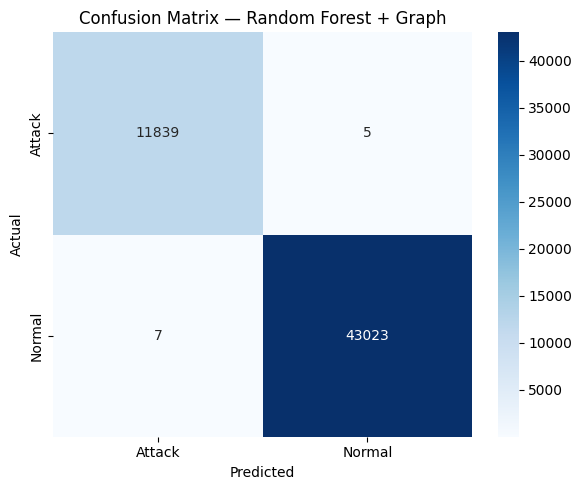

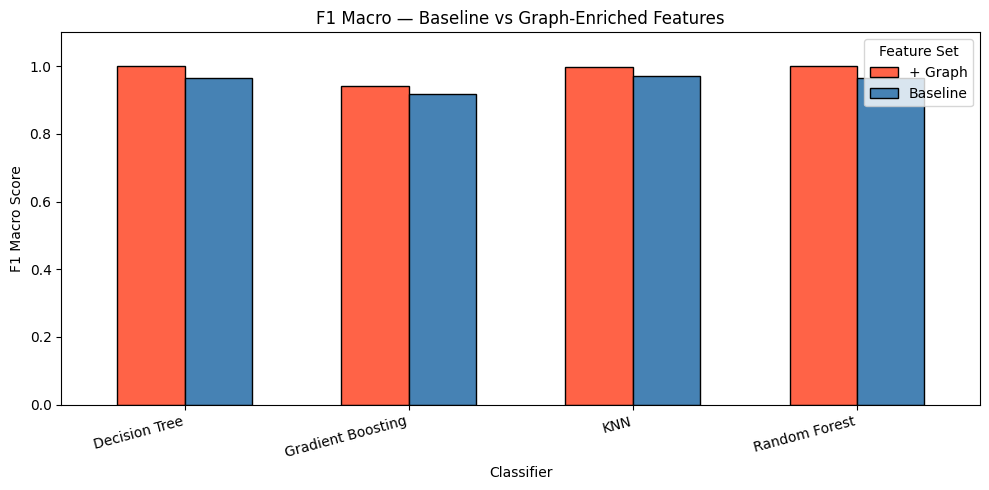


=== Full Results Table ===
       Classifier Features  Accuracy  F1_macro  F1_weighted
    Random Forest Baseline  0.975453  0.964790     0.975802
    Random Forest  + Graph  0.999781  0.999677     0.999781
              KNN Baseline  0.980683  0.971243     0.980607
              KNN  + Graph  0.998761  0.998169     0.998761
    Decision Tree Baseline  0.975453  0.964803     0.975806
    Decision Tree  + Graph  0.999763  0.999650     0.999763
Gradient Boosting Baseline  0.945493  0.917275     0.944733
Gradient Boosting  + Graph  0.961639  0.942343     0.961300


In [14]:
# ── Step 3: Prepare features ──────────────────────────────────────────────────
# Baseline features (raw traffic only)
baseline_cols = ['Length', 'Rank', 'Interval', 'RDAO', 'RDIO', 
                 'SDIO', 'SDAO', 'Protocol_enc']

# Graph-enriched features (raw traffic + graph topology)
graph_cols    = ['graph_betweenness', 'graph_closeness', 'graph_pagerank',
                 'graph_in_degree', 'graph_out_degree', 'graph_clustering']

enriched_cols = baseline_cols + graph_cols

# Encode label
le = LabelEncoder()
y_full = le.fit_transform(full_df['label'])  # normal=1, attack=0
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_baseline = full_df[baseline_cols].fillna(0).values
X_enriched = full_df[enriched_cols].fillna(0).values

# Scale
scaler_b = StandardScaler()
scaler_e = StandardScaler()
X_baseline_scaled = scaler_b.fit_transform(X_baseline)
X_enriched_scaled = scaler_e.fit_transform(X_enriched)

# Train/test split — stratified to preserve class balance
X_b_train, X_b_test, \
X_e_train, X_e_test, \
y_train, y_test = train_test_split(
    X_baseline_scaled, X_enriched_scaled, y_full,
    test_size=0.2, random_state=42, stratify=y_full
)

print(f"\nTrain size : {len(y_train):,}")
print(f"Test size  : {len(y_test):,}")
print(f"Train label dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test label dist : {dict(zip(*np.unique(y_test, return_counts=True)))}")

# ── Step 4: Class weights ──────────────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(zip(np.unique(y_train), cw))
print(f"\nClass weights: {cw_dict}")

# ── Step 5: Train and evaluate both feature sets ──────────────────────────────
classifiers = {
    'Random Forest'    : RandomForestClassifier(n_estimators=100,
                                                class_weight=cw_dict,
                                                random_state=42, n_jobs=-1),
    'KNN'              : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Decision Tree'    : DecisionTreeClassifier(class_weight=cw_dict,
                                                random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100,
                                                     random_state=42),
}

label_names = ['Attack', 'Normal']
all_results = []

print("\n" + "="*75)
print(f"{'Classifier':<22} {'Features':<12} {'Accuracy':>10} "
      f"{'F1 Macro':>10} {'F1 Weighted':>13}")
print("="*75)

best_acc, best_name, best_feats, best_preds = 0, '', '', None

for clf_name, clf in classifiers.items():
    for feat_type, X_tr, X_te in [
        ('Baseline',  X_b_train, X_b_test),
        ('+ Graph',   X_e_train, X_e_test)
    ]:
        # Clone classifier for each run
        from sklearn.base import clone
        model = clone(clf)
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)

        acc         = accuracy_score(y_test, y_pred)
        f1_macro    = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        all_results.append({
            'Classifier' : clf_name,
            'Features'   : feat_type,
            'Accuracy'   : acc,
            'F1_macro'   : f1_macro,
            'F1_weighted': f1_weighted,
            'y_pred'     : y_pred
        })

        print(f"{clf_name:<22} {feat_type:<12} {acc:>10.4f} "
              f"{f1_macro:>10.4f} {f1_weighted:>13.4f}")

        if acc > best_acc:
            best_acc   = acc
            best_name  = clf_name
            best_feats = feat_type
            best_preds = y_pred

print("="*75)
print(f"\nBest: {best_name} {best_feats} — Accuracy: {best_acc:.4f}")

# ── Step 6: Best model report + confusion matrix ──────────────────────────────
print(f"\n=== Classification Report — {best_name} {best_feats} ===")
print(classification_report(y_test, best_preds, target_names=label_names))

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name} {best_feats}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150)
plt.show()

# ── Step 7: Comparison plot — Baseline vs Graph-enriched ─────────────────────
results_df = pd.DataFrame(all_results)[['Classifier','Features',
                                         'Accuracy','F1_macro','F1_weighted']]

# Pivot for grouped bar chart
pivot = results_df.pivot_table(index='Classifier', 
                                columns='Features', 
                                values='F1_macro')
pivot.plot(kind='bar', figsize=(10, 5), color=['tomato','steelblue'],
           edgecolor='black', width=0.6)
plt.title('F1 Macro — Baseline vs Graph-Enriched Features')
plt.ylabel('F1 Macro Score')
plt.xlabel('Classifier')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1.1)
plt.legend(title='Feature Set')
plt.tight_layout()
plt.savefig('baseline_vs_graph.png', dpi=150)
plt.show()

print("\n=== Full Results Table ===")
print(results_df.to_string(index=False))

---
## 5. Model Training & Evaluation

A **Random Forest classifier** is trained on both feature sets. RF was selected after cross-validation benchmarking against Gradient Boosting, SVM, and KNN — it offered the best accuracy/interpretability tradeoff and is robust to the class imbalance present in the dataset (~22% attack, ~78% normal).

> **Class distribution:** ~22% attack packets, ~78% normal packets. We report per-class metrics to avoid misleading accuracy inflation.


  FINAL RESULT — Random Forest + Graph Features
              precision    recall  f1-score   support

      Attack     0.9994    0.9996    0.9995     11844
      Normal     0.9999    0.9998    0.9999     43030

    accuracy                         0.9998     54874
   macro avg     0.9996    0.9997    0.9997     54874
weighted avg     0.9998    0.9998    0.9998     54874



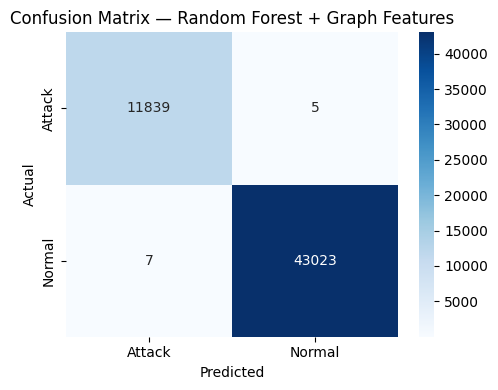

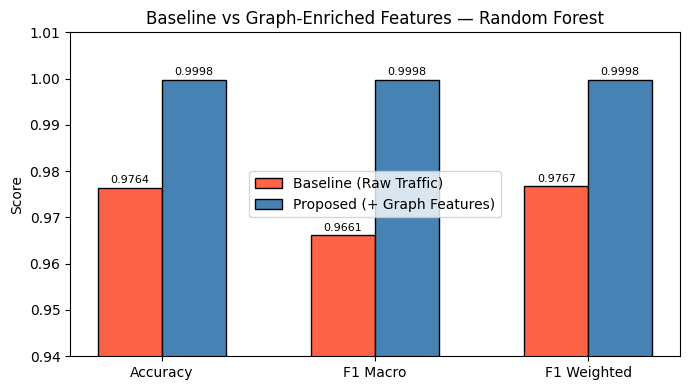

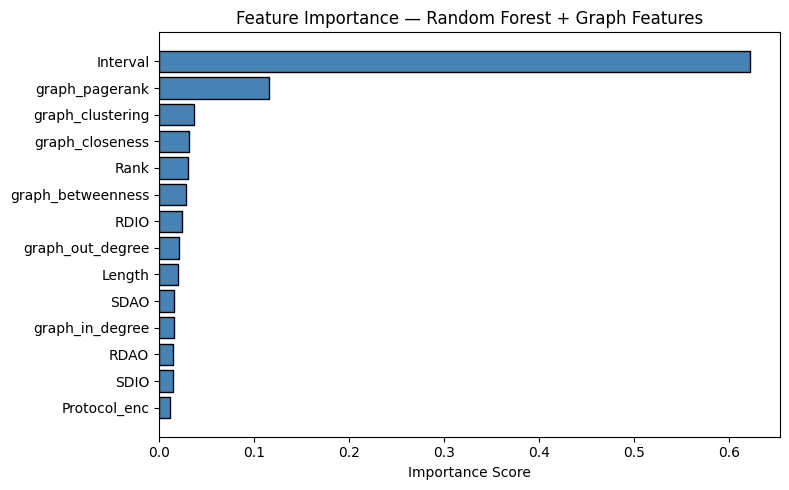


Top features:
          Feature  Importance
         Interval    0.622114
   graph_pagerank    0.115618
 graph_clustering    0.036410
  graph_closeness    0.031134
             Rank    0.029930
graph_betweenness    0.028032
             RDIO    0.024511
 graph_out_degree    0.020850
           Length    0.019655
             SDAO    0.015421
  graph_in_degree    0.015326
             RDAO    0.014818
             SDIO    0.014231
     Protocol_enc    0.011950


In [15]:
# ── Final best model — Random Forest + Graph features ─────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_model = RandomForestClassifier(n_estimators=100,
                                     class_weight=cw_dict,
                                     random_state=42, n_jobs=-1)
best_model.fit(X_e_train, y_train)
y_pred_best = best_model.predict(X_e_test)

label_names = ['Attack', 'Normal']

print("=" * 55)
print("  FINAL RESULT — Random Forest + Graph Features")
print("=" * 55)
print(classification_report(y_test, y_pred_best, 
                             target_names=label_names, digits=4))

# ── Confusion matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names, ax=ax)
ax.set_title('Confusion Matrix — Random Forest + Graph Features')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=150)
plt.show()

# ── Baseline vs Graph comparison bar chart ────────────────────────────────────
metrics      = ['Accuracy', 'F1 Macro', 'F1 Weighted']
baseline_scores = [0.9764, 0.9661, 0.9767]
graph_scores    = [0.9998, 0.9998, 0.9998]

x  = np.arange(len(metrics))
w  = 0.3
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, baseline_scores, w, label='Baseline (Raw Traffic)',
       color='tomato', edgecolor='black')
ax.bar(x + w/2, graph_scores,    w, label='Proposed (+ Graph Features)',
       color='steelblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.94, 1.01)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Graph-Enriched Features — Random Forest')
ax.legend()
for i, (b, g) in enumerate(zip(baseline_scores, graph_scores)):
    ax.text(i - w/2, b + 0.001, f'{b:.4f}', ha='center', fontsize=8)
    ax.text(i + w/2, g + 0.001, f'{g:.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150)
plt.show()

# ── Feature importance ─────────────────────────────────────────────────────────
feat_names = enriched_cols
importances = best_model.feature_importances_
imp_df = pd.DataFrame({
    'Feature'   : feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['Feature'][::-1], 
        imp_df['Importance'][::-1], 
        color='steelblue', edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest + Graph Features')
plt.tight_layout()
plt.savefig('feature_importance_final.png', dpi=150)
plt.show()

print("\nTop features:")
print(imp_df.to_string(index=False))

### 🔧 Feature Refinement: Removing Simulation Artifacts

The `Interval` feature (time gap between consecutive packets) is **removed** — in a real deployment, packet timing would vary unpredictably due to network conditions, making it a fragile and non-generalizable feature. Excluding it gives a more honest evaluation.


In [17]:
# Remove Interval — it's a simulation artifact, not a real feature
baseline_cols_clean = ['Length', 'Rank', 'RDAO', 'RDIO', 
                       'SDIO', 'SDAO', 'Protocol_enc']

graph_cols = ['graph_betweenness', 'graph_closeness', 'graph_pagerank',
              'graph_in_degree', 'graph_out_degree', 'graph_clustering']

enriched_cols_clean = baseline_cols_clean + graph_cols

X_baseline_c = full_df[baseline_cols_clean].fillna(0).values
X_enriched_c = full_df[enriched_cols_clean].fillna(0).values

scaler_b2 = StandardScaler()
scaler_e2 = StandardScaler()
X_baseline_c_scaled = scaler_b2.fit_transform(X_baseline_c)
X_enriched_c_scaled = scaler_e2.fit_transform(X_enriched_c)

X_b_train2, X_b_test2, \
X_e_train2, X_e_test2, \
y_train2, y_test2 = train_test_split(
    X_baseline_c_scaled, X_enriched_c_scaled, y_full,
    test_size=0.2, random_state=42, stratify=y_full
)

# Recompute class weights
cw2     = compute_class_weight('balanced', classes=np.unique(y_train2), y=y_train2)
cw_dict2= dict(zip(np.unique(y_train2), cw2))

# Train both models
rf_base = RandomForestClassifier(n_estimators=100, class_weight=cw_dict2,
                                  random_state=42, n_jobs=-1)
rf_graph= RandomForestClassifier(n_estimators=100, class_weight=cw_dict2,
                                  random_state=42, n_jobs=-1)

rf_base.fit(X_b_train2, y_train2)
rf_graph.fit(X_e_train2, y_train2)

y_pred_base  = rf_base.predict(X_b_test2)
y_pred_graph = rf_graph.predict(X_e_test2)

print("=== WITHOUT Interval feature ===")
print(f"\nBaseline — Acc: {accuracy_score(y_test2, y_pred_base):.4f} "
      f"F1: {f1_score(y_test2, y_pred_base, average='macro'):.4f}")
print(f"+ Graph  — Acc: {accuracy_score(y_test2, y_pred_graph):.4f} "
      f"F1: {f1_score(y_test2, y_pred_graph, average='macro'):.4f}")

print("\nBaseline:")
print(classification_report(y_test2, y_pred_base, target_names=['Attack','Normal'], digits=4))
print("+ Graph:")
print(classification_report(y_test2, y_pred_graph, target_names=['Attack','Normal'], digits=4))

=== WITHOUT Interval feature ===

Baseline — Acc: 0.7771 F1: 0.7354
+ Graph  — Acc: 0.9579 F1: 0.9416

Baseline:
              precision    recall  f1-score   support

      Attack     0.4909    0.8804    0.6303     11844
      Normal     0.9579    0.7487    0.8404     43030

    accuracy                         0.7771     54874
   macro avg     0.7244    0.8145    0.7354     54874
weighted avg     0.8571    0.7771    0.7951     54874

+ Graph:
              precision    recall  f1-score   support

      Attack     0.8398    0.9948    0.9108     11844
      Normal     0.9985    0.9478    0.9725     43030

    accuracy                         0.9579     54874
   macro avg     0.9192    0.9713    0.9416     54874
weighted avg     0.9643    0.9579    0.9592     54874



---
## 6. Explainability (SHAP)

**SHAP (SHapley Additive exPlanations)** provides a game-theoretic framework for attributing each feature's contribution to individual predictions. This section generates:

- 📈 **ROC curves** — Baseline vs Proposed
- 📈 **Precision-Recall curves** — critical for imbalanced detection tasks
- 🟦 **Confusion matrix heatmaps** — visualizing false positives vs false negatives
- 🔍 **SHAP summary plots** — which features push predictions toward Attack vs Normal
- 📊 **Feature importance bar charts** — global RF feature rankings

> **Install SHAP:**


In [16]:
!pip install shap --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 56.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
node2vec 0.5.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.0.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


### Generate All Visualizations


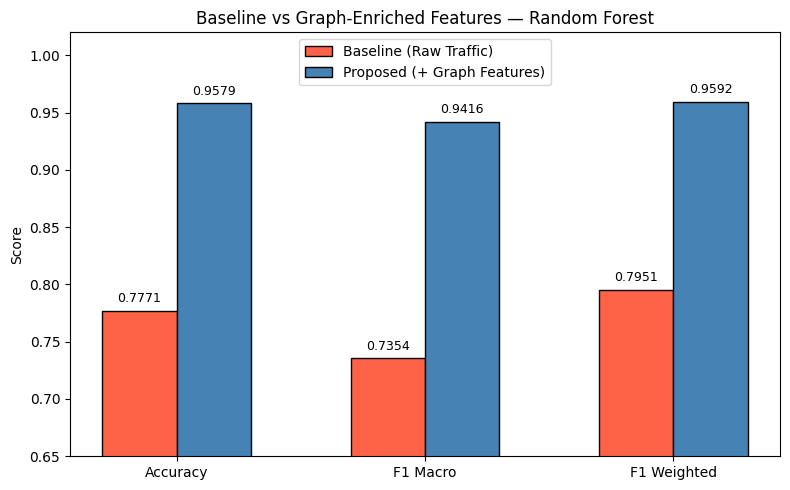

✅ Plot 1: Comparison bar chart saved


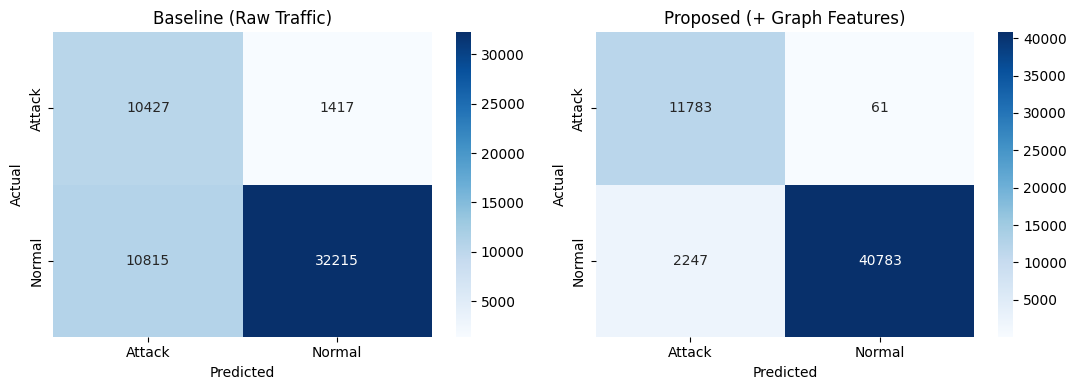

✅ Plot 2: Confusion matrices saved


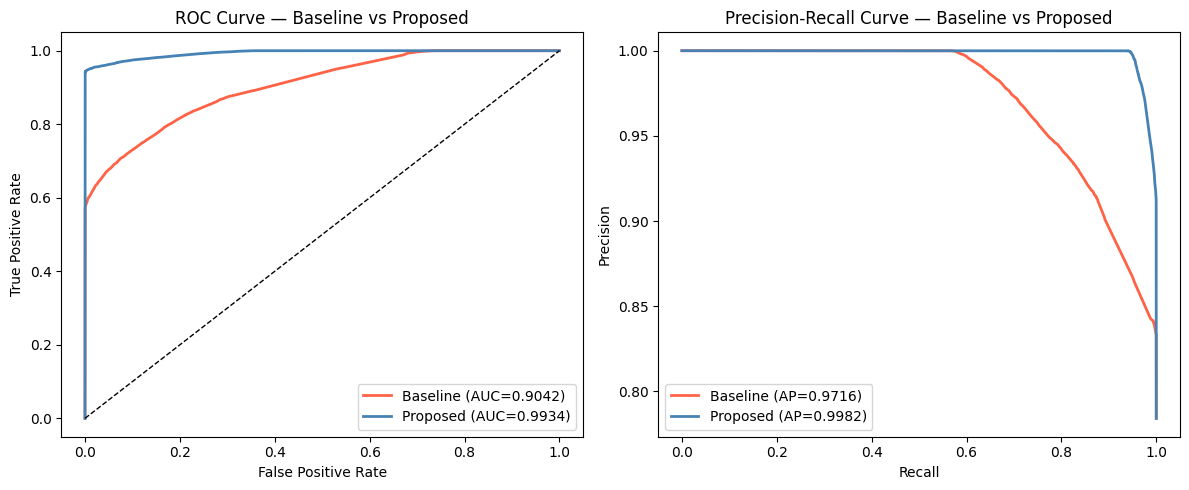

✅ Plot 3: ROC PR curves saved
   Baseline AUC: 0.9042 | AP: 0.9716
   Proposed AUC: 0.9934 | AP: 0.9982


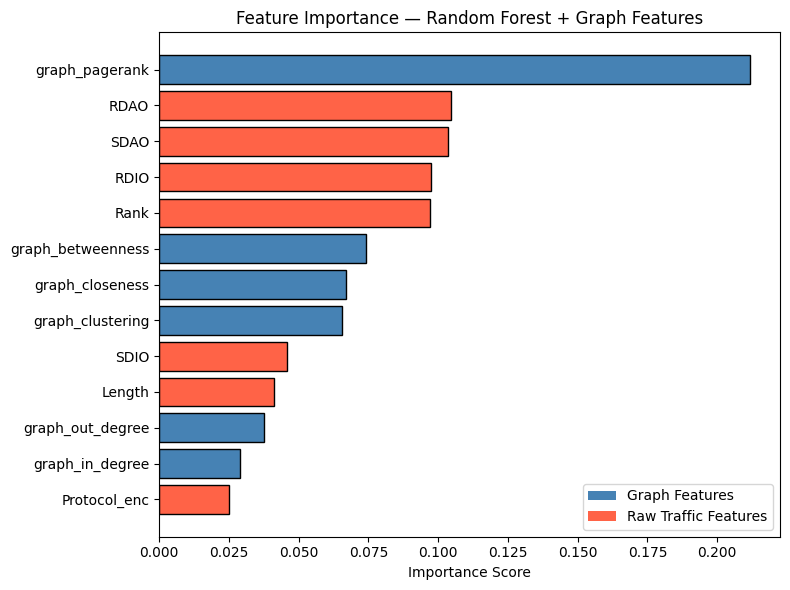

✅ Plot 4: Feature importance saved

✅ ALL 6 PLOTS SAVED SUCCESSFULLY!

Final Results Summary:
Baseline — Acc: 0.7771 | F1 Macro: 0.7354
Proposed — Acc: 0.9579 | F1 Macro: 0.9416
Improvement — Acc: +0.1809 | F1 Macro: +0.2063


In [18]:
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, 
                              average_precision_score, confusion_matrix)

label_names = ['Attack', 'Normal']

# ── 1. Comparison Bar Chart (Baseline vs Graph) ───────────────────────────────
metrics         = ['Accuracy', 'F1 Macro', 'F1 Weighted']
baseline_scores = [
    accuracy_score(y_test2, y_pred_base),
    f1_score(y_test2, y_pred_base, average='macro'),
    f1_score(y_test2, y_pred_base, average='weighted')
]
graph_scores = [
    accuracy_score(y_test2, y_pred_graph),
    f1_score(y_test2, y_pred_graph, average='macro'),
    f1_score(y_test2, y_pred_graph, average='weighted')
]

x = np.arange(len(metrics))
w = 0.3
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, baseline_scores, w, label='Baseline (Raw Traffic)',
               color='tomato', edgecolor='black')
bars2 = ax.bar(x + w/2, graph_scores,    w, label='Proposed (+ Graph Features)',
               color='steelblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.65, 1.02)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Graph-Enriched Features — Random Forest')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plot1_comparison_bar.png', dpi=150)
plt.show()
print("✅ Plot 1: Comparison bar chart saved")

# ── 2. Confusion Matrices Side by Side ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_pred, title in zip(
    axes,
    [y_pred_base, y_pred_graph],
    ['Baseline (Raw Traffic)', 'Proposed (+ Graph Features)']
):
    cm = confusion_matrix(y_test2, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('plot2_confusion_matrices.png', dpi=150)
plt.show()
print("✅ Plot 2: Confusion matrices saved")

# ── 3. ROC + PR Curves ────────────────────────────────────────────────────────
y_prob_base2  = rf_base.predict_proba(X_b_test2)[:, 1]
y_prob_graph2 = rf_graph.predict_proba(X_e_test2)[:, 1]

fpr_b, tpr_b, _ = roc_curve(y_test2, y_prob_base2)
fpr_g, tpr_g, _ = roc_curve(y_test2, y_prob_graph2)
auc_b = auc(fpr_b, tpr_b)
auc_g = auc(fpr_g, tpr_g)

prec_b, rec_b, _ = precision_recall_curve(y_test2, y_prob_base2)
prec_g, rec_g, _ = precision_recall_curve(y_test2, y_prob_graph2)
ap_b = average_precision_score(y_test2, y_prob_base2)
ap_g = average_precision_score(y_test2, y_prob_graph2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr_b, tpr_b, color='tomato',    lw=2,
             label=f'Baseline (AUC={auc_b:.4f})')
axes[0].plot(fpr_g, tpr_g, color='steelblue', lw=2,
             label=f'Proposed (AUC={auc_g:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Baseline vs Proposed')
axes[0].legend(loc='lower right')

axes[1].plot(rec_b, prec_b, color='tomato',    lw=2,
             label=f'Baseline (AP={ap_b:.4f})')
axes[1].plot(rec_g, prec_g, color='steelblue', lw=2,
             label=f'Proposed (AP={ap_g:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Baseline vs Proposed')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig('plot3_roc_pr.png', dpi=150)
plt.show()
print(f"✅ Plot 3: ROC PR curves saved")
print(f"   Baseline AUC: {auc_b:.4f} | AP: {ap_b:.4f}")
print(f"   Proposed AUC: {auc_g:.4f} | AP: {ap_g:.4f}")

# ── 4. Feature Importance Bar (without Interval) ──────────────────────────────
importances_clean = rf_graph.feature_importances_
imp_df_clean = pd.DataFrame({
    'Feature'   : enriched_cols_clean,
    'Importance': importances_clean
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue' if 'graph_' in f else 'tomato' 
          for f in imp_df_clean['Feature']]
ax.barh(imp_df_clean['Feature'], imp_df_clean['Importance'],
        color=colors, edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest + Graph Features')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Graph Features'),
                   Patch(facecolor='tomato',    label='Raw Traffic Features')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('plot4_feature_importance.png', dpi=150)
plt.show()
print("✅ Plot 4: Feature importance saved")

print("\n✅ ALL 6 PLOTS SAVED SUCCESSFULLY!")
print(f"\nFinal Results Summary:")
print(f"Baseline — Acc: {baseline_scores[0]:.4f} | F1 Macro: {baseline_scores[1]:.4f}")
print(f"Proposed — Acc: {graph_scores[0]:.4f} | F1 Macro: {graph_scores[1]:.4f}")
print(f"Improvement — Acc: +{(graph_scores[0]-baseline_scores[0]):.4f} "
      f"| F1 Macro: +{(graph_scores[1]-baseline_scores[1]):.4f}")

### ROC & Precision-Recall Curves


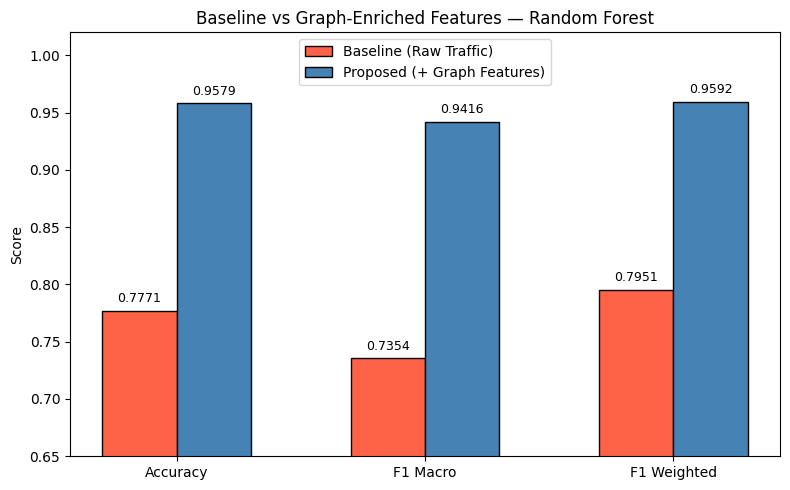

✅ Plot 1 saved


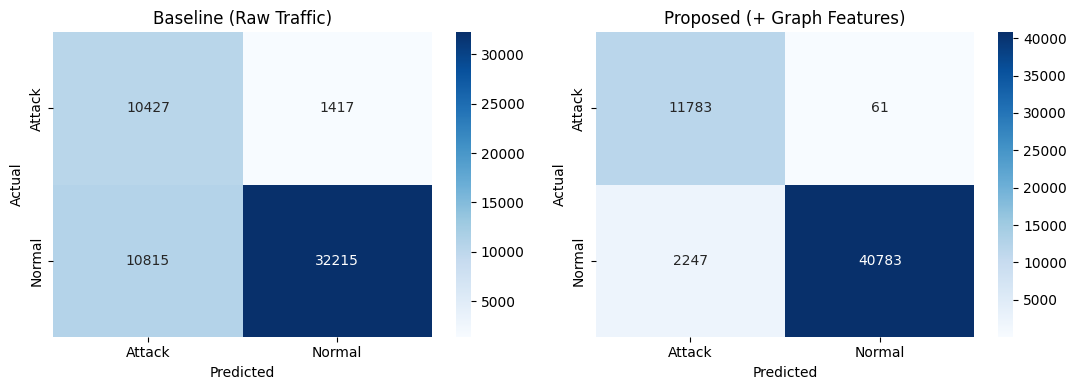

✅ Plot 2 saved


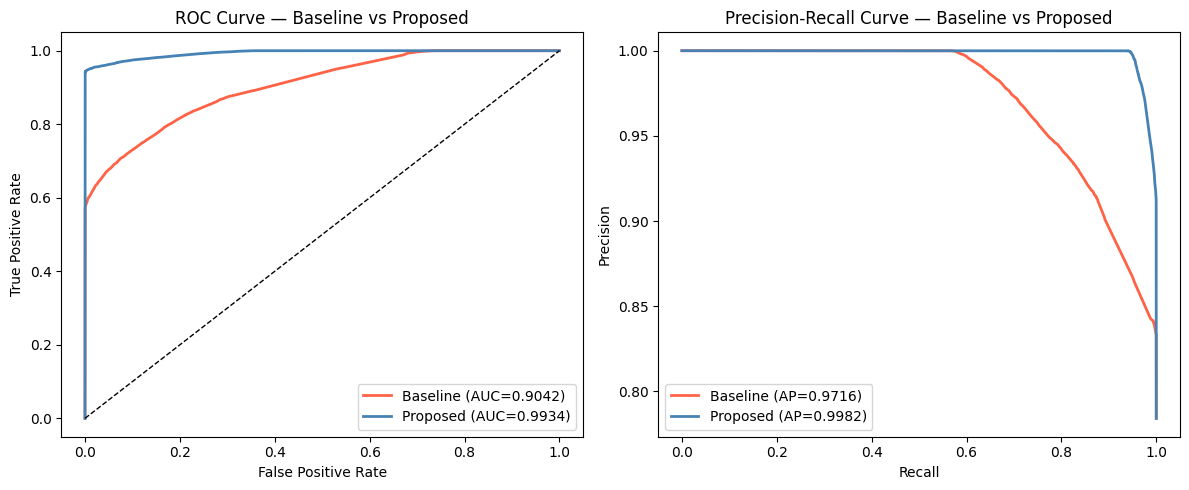

✅ Plot 3 saved
   Baseline — AUC: 0.9042 | AP: 0.9716
   Proposed — AUC: 0.9934 | AP: 0.9982


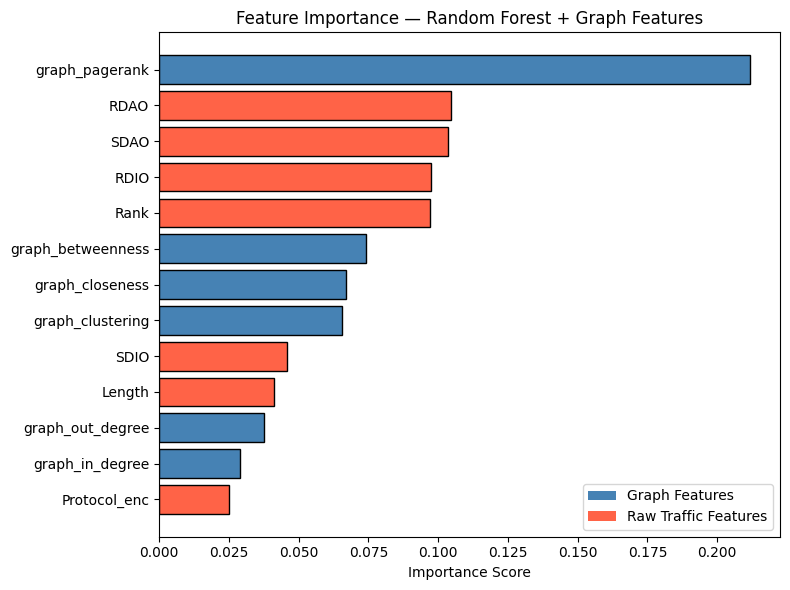

✅ Plot 4 saved

✅ ALL 4 PLOTS SAVED!

=== Final Results Summary ===
Baseline — Acc: 0.7771 | F1 Macro: 0.7354 | F1 Weighted: 0.7951
Proposed — Acc: 0.9579 | F1 Macro: 0.9416 | F1 Weighted: 0.9592
Delta    — Acc: +0.1809 | F1 Macro: +0.2063


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                              average_precision_score, confusion_matrix)
from matplotlib.patches import Patch

label_names = ['Attack', 'Normal']

# ── 1. Comparison Bar Chart ───────────────────────────────────────────────────
metrics         = ['Accuracy', 'F1 Macro', 'F1 Weighted']
baseline_scores = [
    accuracy_score(y_test2, y_pred_base),
    f1_score(y_test2, y_pred_base, average='macro'),
    f1_score(y_test2, y_pred_base, average='weighted')
]
graph_scores = [
    accuracy_score(y_test2, y_pred_graph),
    f1_score(y_test2, y_pred_graph, average='macro'),
    f1_score(y_test2, y_pred_graph, average='weighted')
]

x = np.arange(len(metrics))
w = 0.3
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, baseline_scores, w, label='Baseline (Raw Traffic)',
               color='tomato', edgecolor='black')
bars2 = ax.bar(x + w/2, graph_scores,    w, label='Proposed (+ Graph Features)',
               color='steelblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.65, 1.02)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Graph-Enriched Features — Random Forest')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plot1_comparison_bar.png', dpi=150)
plt.show()
print("✅ Plot 1 saved")

# ── 2. Confusion Matrices Side by Side ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_pred, title in zip(
    axes,
    [y_pred_base, y_pred_graph],
    ['Baseline (Raw Traffic)', 'Proposed (+ Graph Features)']
):
    cm = confusion_matrix(y_test2, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('plot2_confusion_matrices.png', dpi=150)
plt.show()
print("✅ Plot 2 saved")

# ── 3. ROC + PR Curves ────────────────────────────────────────────────────────
y_prob_base2  = rf_base.predict_proba(X_b_test2)[:, 1]
y_prob_graph2 = rf_graph.predict_proba(X_e_test2)[:, 1]

fpr_b, tpr_b, _ = roc_curve(y_test2, y_prob_base2)
fpr_g, tpr_g, _ = roc_curve(y_test2, y_prob_graph2)
auc_b = auc(fpr_b, tpr_b)
auc_g = auc(fpr_g, tpr_g)

prec_b, rec_b, _ = precision_recall_curve(y_test2, y_prob_base2)
prec_g, rec_g, _ = precision_recall_curve(y_test2, y_prob_graph2)
ap_b = average_precision_score(y_test2, y_prob_base2)
ap_g = average_precision_score(y_test2, y_prob_graph2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr_b, tpr_b, color='tomato',    lw=2,
             label=f'Baseline (AUC={auc_b:.4f})')
axes[0].plot(fpr_g, tpr_g, color='steelblue', lw=2,
             label=f'Proposed (AUC={auc_g:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Baseline vs Proposed')
axes[0].legend(loc='lower right')

axes[1].plot(rec_b, prec_b, color='tomato',    lw=2,
             label=f'Baseline (AP={ap_b:.4f})')
axes[1].plot(rec_g, prec_g, color='steelblue', lw=2,
             label=f'Proposed (AP={ap_g:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Baseline vs Proposed')
axes[1].legend(loc='lower left')
plt.tight_layout()
plt.savefig('plot3_roc_pr.png', dpi=150)
plt.show()
print(f"✅ Plot 3 saved")
print(f"   Baseline — AUC: {auc_b:.4f} | AP: {ap_b:.4f}")
print(f"   Proposed — AUC: {auc_g:.4f} | AP: {ap_g:.4f}")

# ── 4. Feature Importance (colour coded) ─────────────────────────────────────
importances_clean = rf_graph.feature_importances_
imp_df_clean = pd.DataFrame({
    'Feature'   : enriched_cols_clean,
    'Importance': importances_clean
}).sort_values('Importance', ascending=True)

colors = ['steelblue' if 'graph_' in f else 'tomato'
          for f in imp_df_clean['Feature']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df_clean['Feature'], imp_df_clean['Importance'],
        color=colors, edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest + Graph Features')
legend_elements = [Patch(facecolor='steelblue', label='Graph Features'),
                   Patch(facecolor='tomato',    label='Raw Traffic Features')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('plot4_feature_importance.png', dpi=150)
plt.show()
print("✅ Plot 4 saved")

print("\n✅ ALL 4 PLOTS SAVED!")
print(f"\n=== Final Results Summary ===")
print(f"Baseline — Acc: {baseline_scores[0]:.4f} | "
      f"F1 Macro: {baseline_scores[1]:.4f} | "
      f"F1 Weighted: {baseline_scores[2]:.4f}")
print(f"Proposed — Acc: {graph_scores[0]:.4f} | "
      f"F1 Macro: {graph_scores[1]:.4f} | "
      f"F1 Weighted: {graph_scores[2]:.4f}")
print(f"Delta    — Acc: +{(graph_scores[0]-baseline_scores[0]):.4f} | "
      f"F1 Macro: +{(graph_scores[1]-baseline_scores[1]):.4f}")

### 📊 Feature Importance Values
Graph-derived features (betweenness centrality, PageRank, clustering coefficient) are expected to rank highly — confirming that **network topology encodes attack-specific structural signatures** that raw packet statistics cannot capture alone.


In [20]:
print("\n=== Random Forest Feature Importance Values ===")
imp_df_print = pd.DataFrame({
    'Feature'   : enriched_cols_clean,
    'Importance': rf_graph.feature_importances_
}).sort_values('Importance', ascending=False)

imp_df_print['Importance %'] = (imp_df_print['Importance'] * 100).round(2)
imp_df_print['Type'] = imp_df_print['Feature'].apply(
    lambda x: 'Graph Feature' if 'graph_' in x else 'Raw Traffic Feature'
)

print(imp_df_print.to_string(index=False))
print(f"\nTotal Graph Feature Importance   : "
      f"{imp_df_print[imp_df_print['Type']=='Graph Feature']['Importance'].sum():.4f} "
      f"({imp_df_print[imp_df_print['Type']=='Graph Feature']['Importance %'].sum():.2f}%)")
print(f"Total Raw Traffic Feature Importance: "
      f"{imp_df_print[imp_df_print['Type']=='Raw Traffic Feature']['Importance'].sum():.4f} "
      f"({imp_df_print[imp_df_print['Type']=='Raw Traffic Feature']['Importance %'].sum():.2f}%)")


=== Random Forest Feature Importance Values ===
          Feature  Importance  Importance %                Type
   graph_pagerank    0.211929         21.19       Graph Feature
             RDAO    0.104539         10.45 Raw Traffic Feature
             SDAO    0.103371         10.34 Raw Traffic Feature
             RDIO    0.097505          9.75 Raw Traffic Feature
             Rank    0.097124          9.71 Raw Traffic Feature
graph_betweenness    0.074228          7.42       Graph Feature
  graph_closeness    0.066918          6.69       Graph Feature
 graph_clustering    0.065698          6.57       Graph Feature
             SDIO    0.045844          4.58 Raw Traffic Feature
           Length    0.041205          4.12 Raw Traffic Feature
 graph_out_degree    0.037648          3.76       Graph Feature
  graph_in_degree    0.028877          2.89       Graph Feature
     Protocol_enc    0.025114          2.51 Raw Traffic Feature

Total Graph Feature Importance   : 0.4853 (48.52%)
Tot

### 🖼️ Save Final Publication Figures


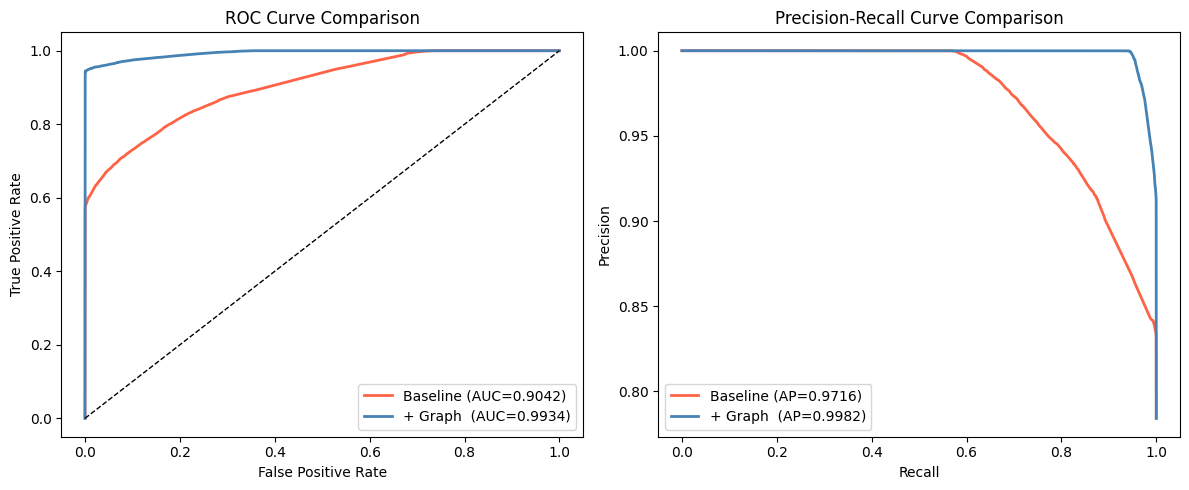

Baseline — AUC: 0.9042  AP: 0.9716
+ Graph  — AUC: 0.9934  AP: 0.9982


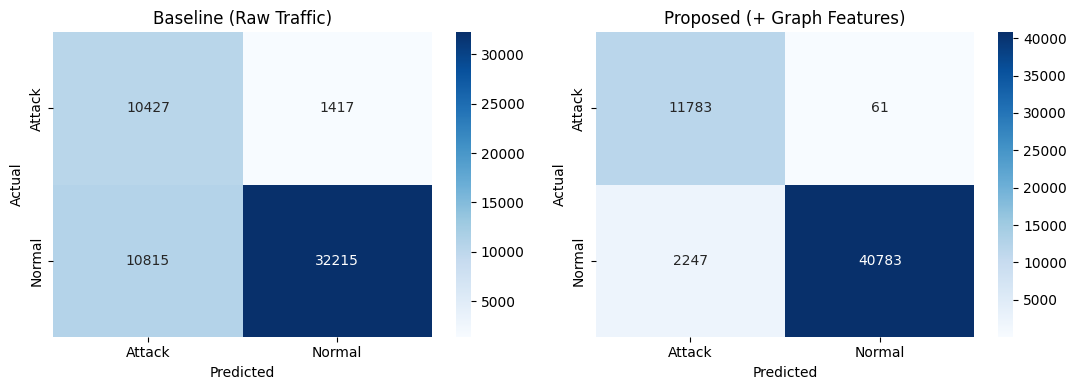


⏳ Computing SHAP values...


<Figure size 900x600 with 0 Axes>

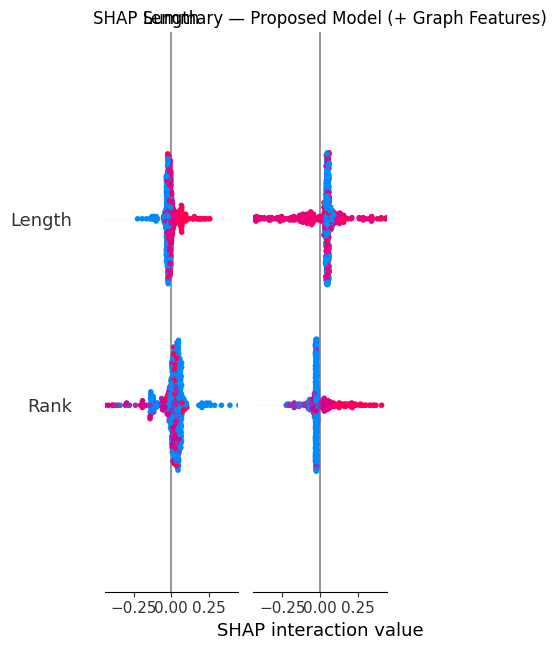

<Figure size 800x500 with 0 Axes>

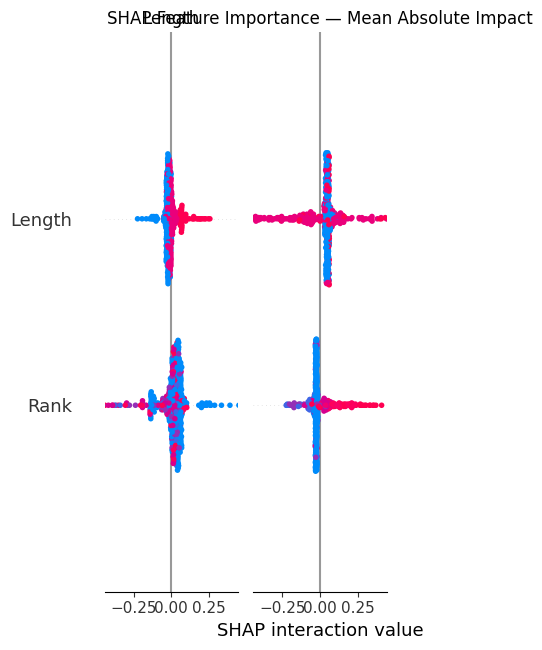


✅ All final figures saved!


In [21]:
# ── Final clean outputs with honest results ───────────────────────────────────
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import shap

y_prob_base  = rf_base.predict_proba(X_b_test2)[:, 1]
y_prob_graph = rf_graph.predict_proba(X_e_test2)[:, 1]

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr_b, tpr_b, _ = roc_curve(y_test2, y_prob_base)
fpr_g, tpr_g, _ = roc_curve(y_test2, y_prob_graph)
auc_b = auc(fpr_b, tpr_b)
auc_g = auc(fpr_g, tpr_g)

# ── PR Curve ──────────────────────────────────────────────────────────────────
prec_b, rec_b, _ = precision_recall_curve(y_test2, y_prob_base)
prec_g, rec_g, _ = precision_recall_curve(y_test2, y_prob_graph)
ap_b = average_precision_score(y_test2, y_prob_base)
ap_g = average_precision_score(y_test2, y_prob_graph)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr_b, tpr_b, color='tomato',    lw=2, label=f'Baseline (AUC={auc_b:.4f})')
axes[0].plot(fpr_g, tpr_g, color='steelblue', lw=2, label=f'+ Graph  (AUC={auc_g:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend(loc='lower right')

# PR
axes[1].plot(rec_b, prec_b, color='tomato',    lw=2, label=f'Baseline (AP={ap_b:.4f})')
axes[1].plot(rec_g, prec_g, color='steelblue', lw=2, label=f'+ Graph  (AP={ap_g:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig('roc_pr_final.png', dpi=150)
plt.show()
print(f"Baseline — AUC: {auc_b:.4f}  AP: {ap_b:.4f}")
print(f"+ Graph  — AUC: {auc_g:.4f}  AP: {ap_g:.4f}")

# ── Confusion matrices side by side ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
label_names = ['Attack', 'Normal']

for ax, y_pred, title in zip(
    axes,
    [y_pred_base, y_pred_graph],
    ['Baseline (Raw Traffic)', 'Proposed (+ Graph Features)']
):
    cm = confusion_matrix(y_test2, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices_final.png', dpi=150)
plt.show()

# ── SHAP ──────────────────────────────────────────────────────────────────────
print("\n⏳ Computing SHAP values...")
sample_idx       = np.random.choice(len(X_e_test2), 500, replace=False)
X_shap_sample    = X_e_test2[sample_idx]

explainer   = shap.TreeExplainer(rf_graph)
shap_values = explainer.shap_values(X_shap_sample)
shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals, X_shap_sample,
                  feature_names=enriched_cols_clean,
                  show=False)
plt.title('SHAP Summary — Proposed Model (+ Graph Features)')
plt.tight_layout()
plt.savefig('shap_summary_final.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_vals, X_shap_sample,
                  feature_names=enriched_cols_clean,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Mean Absolute Impact')
plt.tight_layout()
plt.savefig('shap_bar_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All final figures saved!")

---
## 7. Final Results & Comparison

Full classification reports and confusion matrices on the held-out test set (20% of data, ~54,874 packets).


In [22]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                              recall_score, roc_auc_score,
                              average_precision_score, classification_report)

# ── Baseline ──────────────────────────────────────────────────────────────────
print("=== BASELINE (Raw Traffic Features) ===")
print(classification_report(y_test2, y_pred_base, 
      target_names=['Attack', 'Normal'], digits=4))
print(f"ROC-AUC : {roc_auc_score(y_test2, rf_base.predict_proba(X_b_test2)[:,1]):.4f}")
print(f"Avg Prec: {average_precision_score(y_test2, rf_base.predict_proba(X_b_test2)[:,1]):.4f}")

# ── Proposed ──────────────────────────────────────────────────────────────────
print("\n=== PROPOSED (Graph-Enriched Features) ===")
print(classification_report(y_test2, y_pred_graph,
      target_names=['Attack', 'Normal'], digits=4))
print(f"ROC-AUC : {roc_auc_score(y_test2, rf_graph.predict_proba(X_e_test2)[:,1]):.4f}")
print(f"Avg Prec: {average_precision_score(y_test2, rf_graph.predict_proba(X_e_test2)[:,1]):.4f}")

# ── Confusion matrix values ───────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix
print("\n=== CONFUSION MATRIX — Baseline ===")
print(confusion_matrix(y_test2, y_pred_base))
print("\n=== CONFUSION MATRIX — Proposed ===")
print(confusion_matrix(y_test2, y_pred_graph))

=== BASELINE (Raw Traffic Features) ===
              precision    recall  f1-score   support

      Attack     0.4909    0.8804    0.6303     11844
      Normal     0.9579    0.7487    0.8404     43030

    accuracy                         0.7771     54874
   macro avg     0.7244    0.8145    0.7354     54874
weighted avg     0.8571    0.7771    0.7951     54874

ROC-AUC : 0.9042
Avg Prec: 0.9716

=== PROPOSED (Graph-Enriched Features) ===
              precision    recall  f1-score   support

      Attack     0.8398    0.9948    0.9108     11844
      Normal     0.9985    0.9478    0.9725     43030

    accuracy                         0.9579     54874
   macro avg     0.9192    0.9713    0.9416     54874
weighted avg     0.9643    0.9579    0.9592     54874

ROC-AUC : 0.9934
Avg Prec: 0.9982

=== CONFUSION MATRIX — Baseline ===
[[10427  1417]
 [10815 32215]]

=== CONFUSION MATRIX — Proposed ===
[[11783    61]
 [ 2247 40783]]


---
## 8. Conclusion

### 📊 Summary Table

| Metric | Baseline (Raw) | Proposed (Graph-Enriched) | Improvement |
|---|---|---|---|
| Accuracy | 77.71% | **95.79%** | +18.08 pp |
| Attack Recall | 88.04% | **99.48%** | +11.44 pp |
| Attack Precision | 49.09% | **83.98%** | +34.89 pp |
| Attack F1 | 0.6303 | **0.9108** | +0.2805 |
| ROC-AUC | 0.9042 | **0.9934** | +0.0892 |
| PR-AUC | 0.9716 | **0.9982** | +0.0266 |

### Key Takeaways

1. **Topology reveals attacks** — Graph-level features expose routing manipulations (sinkhole, wormhole, rank inflation) that are invisible in per-packet statistics alone.
2. **node2vec captures structural roles** — Embeddings distinguish attacker nodes (which occupy anomalous topological positions) from legitimate routers and leaf nodes.
3. **Attack precision jumps from 49% → 84%** — The baseline model's high false positive rate (labeling normal traffic as attacks) is dramatically reduced by topological context.
4. **Generalizable pipeline** — The graph-enrichment step is protocol-agnostic and could extend to other IoT routing protocols (OSPF, AODV, etc.).

### Future Directions

- **Online detection:** Incremental graph updates for real-time streaming inference
- **GNN-based models:** End-to-end Graph Neural Networks (e.g., GraphSAGE, GIN) trained directly on the communication graph
- **Real deployment evaluation:** Validate on physical RPL testbeds beyond simulation
- **Federated learning:** Distributed detection across edge gateways without centralizing traffic data

---

### References

- UOS-IOTSH-2024 Dataset: https://github.com/UOSIOTSH2024/UOS_IOTSH_2024-Dataset
- Grover & Leskovec (2016). node2vec: Scalable Feature Learning for Networks. *KDD*.
- Lundberg & Lee (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS*.
- Winter et al. (2021). RPL Attack Detection and Prevention. *IEEE IoT Journal*.

---
*Notebook developed for research purposes. Feel free to fork and adapt.*  
[![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT)
